# Transit-Oriented Development in Greater Boston
## 2026 rebuild

In autumn 2024 I built a model for *Statistics for Design* at Northeastern
(Nabeel Gillani) that picked one MBTA station out of 124 as the best place for
a transit-oriented development. It answered **Quincy Center**. That notebook is
in this repository as `2024-original.ipynb`, exactly as it was submitted.

Two years later I came back to it. This notebook is the second pass. It keeps
the question and almost none of the method, and it arrives somewhere different:
not at one station, but at a shortlist whose order depends on who is asking.

**What changed, in one table:**

| | 2024 | 2026 |
| --- | --- | --- |
| Unit of analysis | community, then station | **site** |
| Stages | two, the first discarding seven communities | one |
| Candidates | 8 communities, then 4 stations | **249 sites in 12 communities** |
| Scale | min-max inside the sample | percentile against 3,028 regional sites |
| Shortlist | none, a single winner | **Pareto frontier, 27 sites, no weights** |
| Weights | one set, justified in prose | **six scenarios, each a stated position** |
| Demand vintage | Fall 2023 | Fall 2025, with a 2017–2025 panel behind it |
| Output | Quincy Center, 82.40 | three winners, depending on the question |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

DATA = 'data/'
FIG = 'figures/'
os.makedirs(FIG, exist_ok=True)

# One palette for every figure in the notebook, so the charts read as a set
# rather than as thirteen separate decisions.
INK, MUTE, FAINT = '#14120C', '#6E685A', '#E2D7BE'
ACCENT, ACCENT2 = '#D03B00', '#3E7C8A'
LINE_COLOR = {'Red': '#DA291C', 'Orange': '#ED8B00', 'Blue': '#003DA5',
              'Green': '#00843D', 'Mattapan': '#DA291C'}

mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': MUTE, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTE, 'ytick.color': MUTE,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': FAINT, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'font.size': 11, 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.titlepad': 12, 'figure.dpi': 100, 'savefig.bbox': 'tight',
})


def save(name):
    plt.savefig(f'{FIG}{name}.png', dpi=200)
    plt.show()


def money(x, _=None):
    return f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'


thousands = FuncFormatter(lambda x, _: f'{x:,.0f}')

## 01. Eligibility is a filter, not a score

The 2024 model scored communities on five indicators and kept the winner. That
conflates two different questions. Whether a community is *eligible* — does the
zoning law apply, is there a rapid transit station — is a yes or no. Whether a
*site* is suitable is a matter of degree. Mixing them into one weighted sum let
a community's average land price stand in for the price of the parcel you would
actually buy.

So eligibility is applied here as a filter and nothing else.

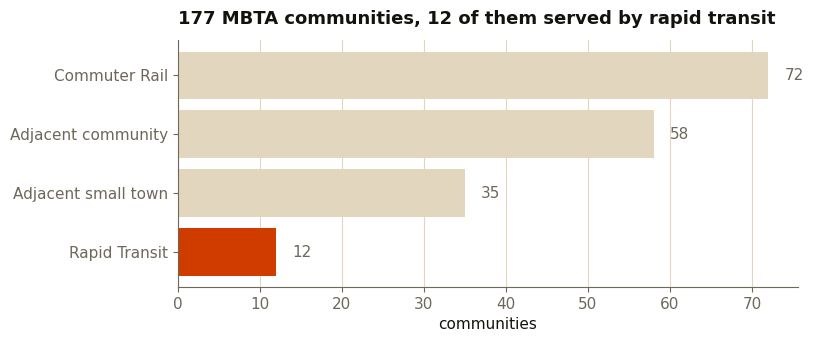

Braintree, Brookline, Cambridge, Chelsea, Everett, Malden, Medford, Milton, Newton, Quincy, Revere, Somerville


In [2]:
com = pd.read_csv(DATA + 'MBTA Communities.csv')
RTC = sorted(com.loc[com.community_category == 'Rapid Transit', 'community'])

counts = com.community_category.value_counts()
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(counts.index[::-1], counts.values[::-1],
               color=[ACCENT if c == 'Rapid Transit' else FAINT for c in counts.index[::-1]])
for b, v in zip(bars, counts.values[::-1]):
    ax.text(v + 2, b.get_y() + b.get_height() / 2, str(v), va='center', color=MUTE)
ax.set_title(f'{len(com)} MBTA communities, {len(RTC)} of them served by rapid transit')
ax.set_xlabel('communities')
ax.grid(axis='y', visible=False)
save('01-eligibility')
print(', '.join(RTC))

## 02. Candidates are sites, because the decision is a site

MAPC's *Rethinking the Retail Strip* inventory carries 3,028 redevelopment
sites across Greater Boston, each with its own land value, buildable area and
the transit station it sits beside. The 2024 model used two of its 64 columns
and averaged them up to the municipality. This one keeps the site.

It also removes a step. The 2024 screening reverse-geocoded 124 stations
through Nominatim to get postcodes and intersected those with community
postcodes. This dataset already names both the municipality and the station, so
the geocoding is unnecessary — and it was lossy: Medford fell out of the 2024
frame entirely.

In [3]:
s = pd.read_csv(DATA + 'mapc.rethinking_retail_sites.csv', low_memory=False)
s['ppa'] = s.land_value / s.sitearea_a

steps = [('MAPC sites, region-wide', len(s))]
site = s[s.municipal.isin(RTC)].copy()
steps.append(('in a Rapid Transit Community', len(site)))
site = site[site.stattyp == 'Rapid Transit']
steps.append(('beside a rapid transit station', len(site)))
site['station'] = site.statname.str.replace(' Glx', '', regex=False).str.strip()

### Demand, measured in the most recent autumn

Section 06 shows why the vintage matters: Fall 2023, which the 2024 model used,
was a trough. Fall 2025 is the freshest release. It reports ridership by hour
rather than by service-planning period, so the peak window has to be defined
here — and the definition is checked against the period-based Fall 2024 file
rather than asserted.

In [4]:
def load_ridership(fn):
    d = pd.read_csv(DATA + fn, encoding='utf-8-sig', low_memory=False)
    d.columns = [c.lower() for c in d.columns]
    d['day_type'] = d.day_type_name.str.lower()
    d['flow'] = d.average_ons + d.average_offs
    return d


f25 = load_ridership('Fall_2025_MBTA_Rail_Ridership_by_Hour_RouteLine_and_Stop.csv')
f24 = load_ridership('Fall_2024_MBTA_Rail_Ridership_by_SDP_Time_Period_Route_Line_and_Stop.csv')
f25['hour'] = f25.hour_of_service.str.slice(0, 2).astype(int)

wd24 = f24[f24.day_type == 'weekday']
peak24 = (wd24[wd24.time_period_name.str.contains('AM_PEAK|PM_PEAK', na=False)]
          .groupby('stop_name').flow.sum() / wd24.groupby('stop_name').flow.sum())

wd25, we25 = f25[f25.day_type == 'weekday'], f25[f25.day_type.isin(['saturday', 'sunday'])]
wd_flow = wd25.groupby('stop_name').flow.sum()

trial = {}
for am, pm in [((7, 8), (16, 17)), ((7, 8, 9), (16, 17, 18)),
               ((6, 7, 8), (15, 16, 17, 18)), ((7, 8), (17, 18))]:
    hrs = set(am) | set(pm)
    ps = wd25[wd25.hour.isin(hrs)].groupby('stop_name').flow.sum() / wd_flow
    trial[f'{min(am)}-{max(am)+1}, {min(pm)}-{max(pm)+1}'] = \
        pd.concat([ps, peak24], axis=1).dropna().corr().iloc[0, 1]
trial = pd.Series(trial).sort_values(ascending=False)
print('agreement with the Fall 2024 period definition:')
print(trial.round(3).to_string())

PEAK_HOURS = {7, 8, 9, 16, 17, 18}
we_flow = we25.groupby('stop_name').flow.sum() / 2
station = pd.DataFrame({
    'daily': (wd_flow * 5 + we_flow * 2) / 7,
    'weekend': we_flow,
    'peak_share': wd25[wd25.hour.isin(PEAK_HOURS)].groupby('stop_name').flow.sum() / wd_flow,
    'wkday_wknd': wd_flow / we_flow,
    'line': f25.groupby('stop_name').route_id.agg(lambda x: sorted(set(x))[0]),
})
station['line'] = station.line.str.split('-').str[0]

site = site.join(station.drop(columns='line'), on='station')
site['line'] = site.station.map(station.line)
steps.append(('joined to Fall 2025 ridership', int(site.daily.notna().sum())))
site = site.dropna(subset=['daily'])

n = len(site)
site = site[(site.ppa > 0) & (site.buildar_ac > 0)]
steps.append(('land value and buildable area above zero', len(site)))
site = site[(site.excl_p < 50) & (site.fz100_p < 50)]
steps.append(('under half excluded land or flood zone', len(site)))

agreement with the Fall 2024 period definition:
7-10, 16-19    0.958
7-9, 17-19     0.935
7-9, 16-18     0.929
6-9, 15-19     0.848


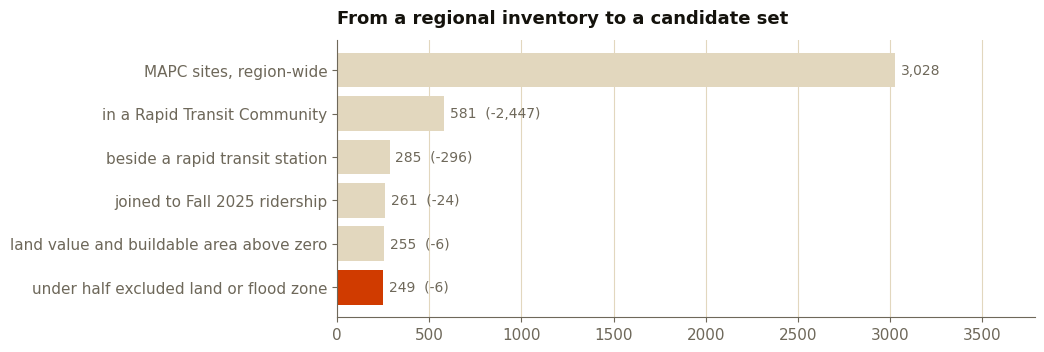

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
labels = [a for a, _ in steps][::-1]
vals = [b for _, b in steps][::-1]
bars = ax.barh(labels, vals, color=[ACCENT] + [FAINT] * (len(vals) - 1))
for b, v, prev in zip(bars, vals, vals[1:] + [None]):
    drop = '' if prev is None else f'  ({v - prev:+,})'
    ax.text(v + 30, b.get_y() + b.get_height() / 2, f'{v:,}{drop}', va='center',
            color=MUTE, fontsize=10)
ax.set_title('From a regional inventory to a candidate set')
ax.set_xlim(0, max(vals) * 1.25)
ax.grid(axis='y', visible=False)
save('02-screening')

## 03. What each indicator looks like before anything is done to it

Four quantities, each in its own units. Land price and buildable area are
properties of the parcel; ridership and peak share are properties of the
station it sits beside. Plotting them first is not decoration: three of the
four are heavily skewed, which is exactly the shape that makes a mean
misleading and a percentile honest.

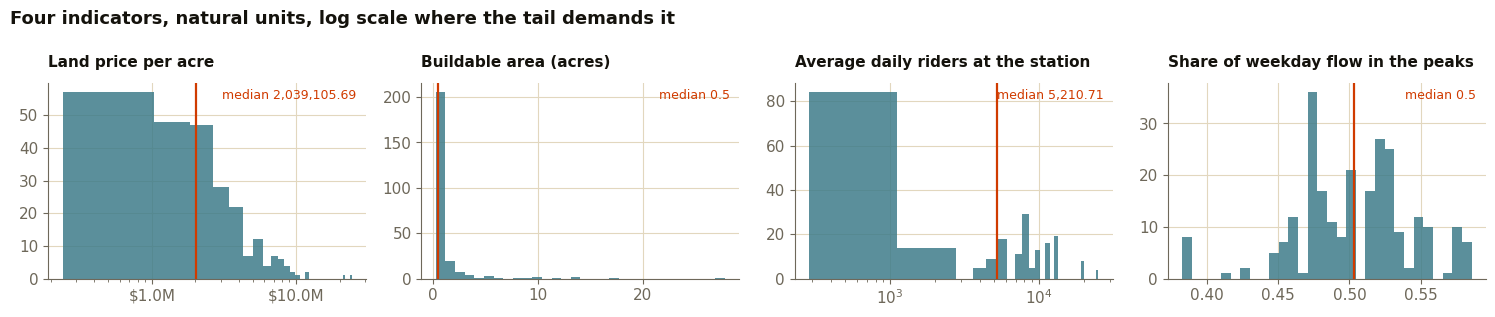

In [6]:
IND = ['ppa', 'buildar_ac', 'daily', 'peak_share']
LOWER_IS_BETTER = {'ppa', 'peak_share'}
NICE = {'ppa': 'Land price per acre', 'buildar_ac': 'Buildable area (acres)',
        'daily': 'Average daily riders at the station', 'peak_share': 'Share of weekday flow in the peaks'}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, c in zip(axes, IND):
    v = site[c]
    ax.hist(v, bins=30, color=ACCENT2, alpha=0.85)
    ax.axvline(v.median(), color=ACCENT, lw=1.6)
    ax.set_title(NICE[c], fontsize=11)
    ax.text(0.97, 0.92, f'median {v.median():,.2f}'.rstrip('0').rstrip('.'),
            transform=ax.transAxes, ha='right', color=ACCENT, fontsize=9)
    if c in ('ppa', 'daily'):
        ax.set_xscale('log')
    if c == 'ppa':
        ax.xaxis.set_major_formatter(FuncFormatter(money))
fig.suptitle('Four indicators, natural units, log scale where the tail demands it',
             x=0.005, ha='left', fontweight='bold', fontsize=13)
plt.tight_layout()
save('03-distributions')

## 04. Two of the 2024 indicators were the same indicator

The 2024 station model weighted average daily ridership at 40% and average
weekend ridership at 20%. Across these sites those two correlate at 0.98. Sixty
per cent of that model's weight was on one quantity entered twice under two
names. Buildable area and estimated mixed-use capacity are the same trap at
0.96.

Checking this costs one line and it decides what the weights actually mean.

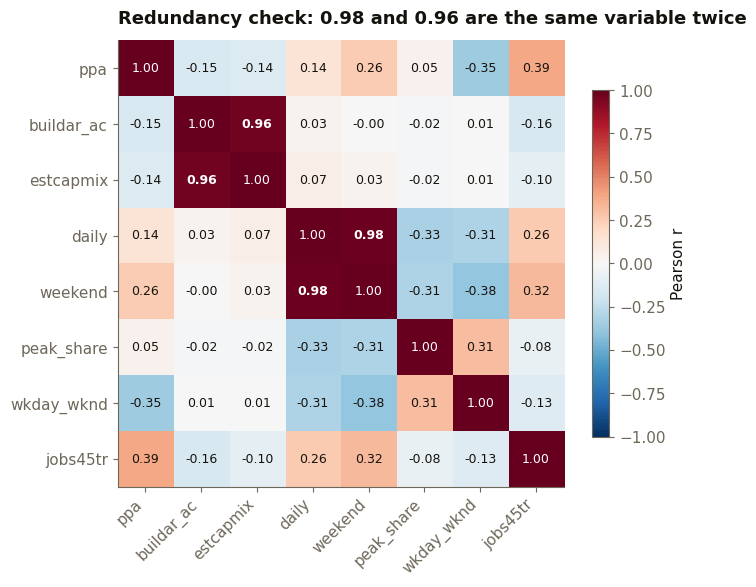

dropped as redundant: weekend (r=0.98 with daily), estcapmix (r=0.96 with buildar_ac)


In [7]:
CAND = ['ppa', 'buildar_ac', 'estcapmix', 'daily', 'weekend', 'peak_share', 'wkday_wknd', 'jobs45tr']
corr = site[CAND].corr()

fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(CAND)), CAND, rotation=45, ha='right')
ax.set_yticks(range(len(CAND)), CAND)
for i in range(len(CAND)):
    for j in range(len(CAND)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 else INK,
                fontweight='bold' if i != j and abs(v) > 0.9 else 'normal')
ax.set_title('Redundancy check: 0.98 and 0.96 are the same variable twice')
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.75, label='Pearson r')
save('04-correlation')

print('dropped as redundant: weekend (r=%.2f with daily), estcapmix (r=%.2f with buildar_ac)'
      % (corr.loc['daily', 'weekend'], corr.loc['buildar_ac', 'estcapmix']))

## 05. Is the Green Line's problem its service?

Half the candidate sites sit on Green Line branches, and the branches have a
reputation for being slow. That is a testable claim, and three independent
measurements disagree with it.

The service data is one Saturday (3 February 2024), so it can describe how the
lines are built but not how reliable they are. Stop-to-stop time and station
dwell are structural; a single day is enough for those. Headway on a Saturday
is not a weekday headway and is labelled as such.

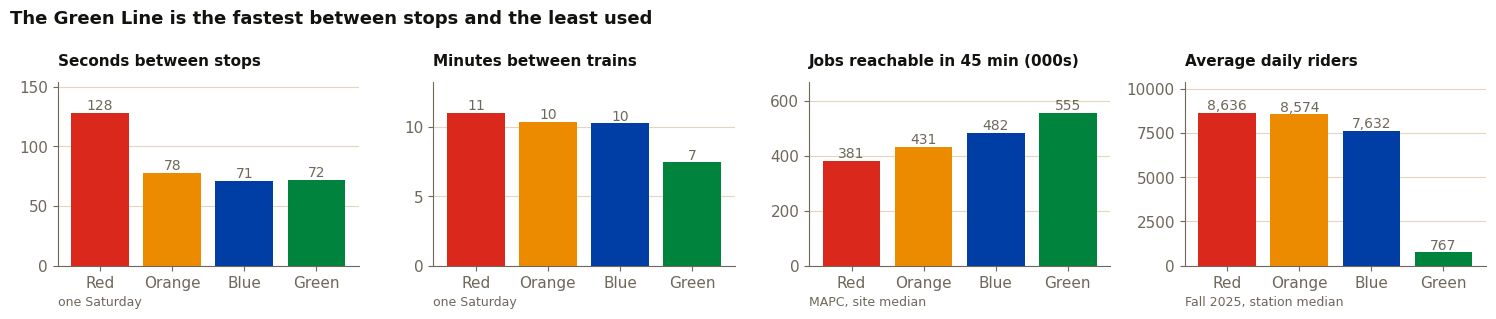

In [8]:
otp = pd.read_parquet(DATA + '2024-02-03-subway-on-time-performance-v1.parquet')
svc = otp.groupby('trunk_route_id').agg(
    sec_per_hop=('travel_time_seconds', 'median'),
    dwell=('dwell_time_seconds', 'median'),
    headway_min=('headway_trunk_seconds', lambda x: x.median() / 60)).drop('Mattapan', errors='ignore')

jobs = site.groupby('line').jobs45tr.median()
riders = station.groupby('line').daily.median().drop('Mattapan', errors='ignore')
panel_lines = ['Red', 'Orange', 'Blue', 'Green']

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
series = [(svc.sec_per_hop, 'Seconds between stops', 'one Saturday'),
          (svc.headway_min, 'Minutes between trains', 'one Saturday'),
          (jobs / 1000, 'Jobs reachable in 45 min (000s)', 'MAPC, site median'),
          (riders, 'Average daily riders', 'Fall 2025, station median')]
for ax, (ser, title, note) in zip(axes, series):
    v = ser.reindex(panel_lines).dropna()
    ax.bar(v.index, v.values, color=[LINE_COLOR[i] for i in v.index])
    for i, (k, val) in enumerate(v.items()):
        ax.text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=10, color=MUTE)
    ax.set_title(title, fontsize=11)
    ax.text(0.0, -0.22, note, transform=ax.transAxes, fontsize=9, color=MUTE)
    ax.set_ylim(0, v.max() * 1.2)
    ax.grid(axis='x', visible=False)
fig.suptitle('The Green Line is the fastest between stops and the least used',
             x=0.005, ha='left', fontweight='bold', fontsize=13)
plt.tight_layout()
save('05-by-line')

**The Green Line branches have the shortest hop times, the most frequent
service and the best regional job access of any line in the candidate set, and
roughly a tenth of the ridership.** What makes a Green Line trip slow is the
number of stops, not the speed between them — and whatever is holding those
sites back, it is not the service they get.

## 06. Six autumns, and why the vintage matters

Every number in the 2024 model came from Fall 2023. Adding Fall 2017, 2018,
2019, 2024 and 2025 turns a snapshot into a trajectory, and the trajectory says
the snapshot was taken at the bottom.

MBTA flags a track-circuit problem in the Fall 2018 file, so Fall 2019 is used
as the pre-pandemic baseline.

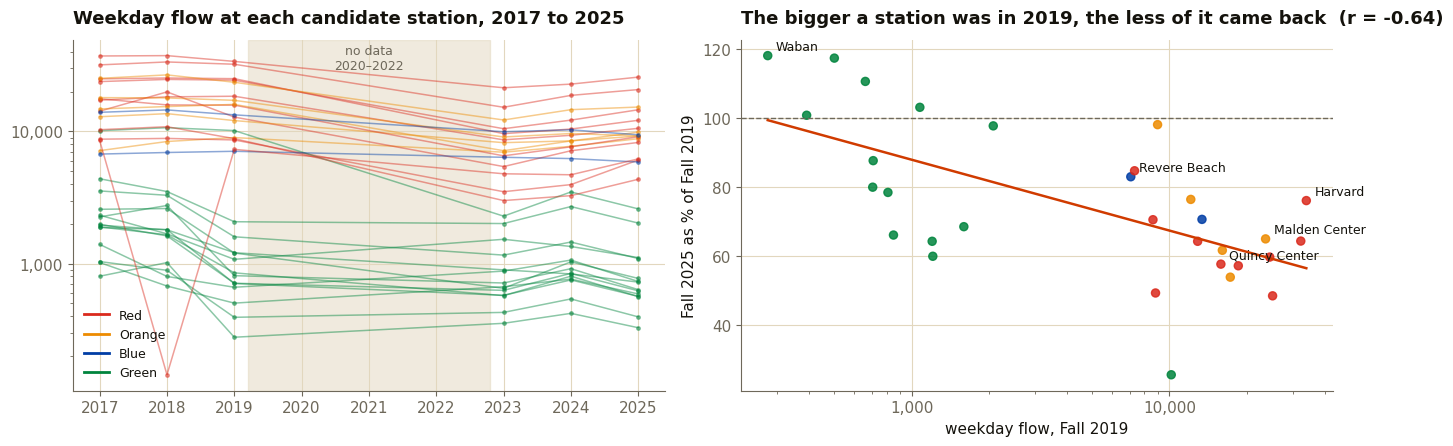

median flow change across candidate stations, Fall 2023 to Fall 2025: +12.3%


In [9]:
def season_panel():
    old = load_ridership('Rail_Ridership_by_Season_Time_Period_RouteLine_and_Stop.csv')
    f23 = load_ridership('Fall_2023_MBTA_Rail_Ridership_Data.csv')
    allr = pd.concat([old, f23, f24, f25], ignore_index=True)
    wd = allr[allr.day_type == 'weekday']
    p = wd.groupby(['stop_name', 'season']).flow.sum().unstack('season')
    return p[[c for c in ['Fall 2017', 'Fall 2018', 'Fall 2019', 'Fall 2023',
                          'Fall 2024', 'Fall 2025'] if c in p.columns]]


panel = season_panel()
cand_st = sorted(site.station.unique())
pc = panel.reindex(cand_st).dropna(subset=['Fall 2019', 'Fall 2025'])
pc = pc.assign(recovery=pc['Fall 2025'] / pc['Fall 2019'] * 100,
               line=[station.line.get(i) for i in pc.index])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6))
years = [2017, 2018, 2019, 2023, 2024, 2025]
cols = [c for c in panel.columns]
for st_name, row in pc.iterrows():
    ax1.plot(years, [row[c] for c in cols], color=LINE_COLOR.get(row.line, MUTE),
             alpha=0.45, lw=1.1, marker='o', ms=2.5)
ax1.set_yscale('log')
ax1.set_title('Weekday flow at each candidate station, 2017 to 2025')
ax1.yaxis.set_major_formatter(thousands)
ax1.axvspan(2019.2, 2022.8, color=FAINT, alpha=0.5)
ax1.text(2021, ax1.get_ylim()[1] * 0.6, 'no data\n2020–2022', ha='center', color=MUTE, fontsize=9)
for ln, c in LINE_COLOR.items():
    if ln in pc.line.values:
        ax1.plot([], [], color=c, label=ln, lw=2)
ax1.legend(frameon=False, fontsize=9, loc='lower left')

ax2.scatter(pc['Fall 2019'], pc.recovery, s=34,
            c=[LINE_COLOR.get(l, MUTE) for l in pc.line], alpha=0.85)
ax2.set_xscale('log')
ax2.axhline(100, color=MUTE, lw=1, ls='--')
r = np.corrcoef(np.log(pc['Fall 2019']), pc.recovery)[0, 1]
z = np.polyfit(np.log(pc['Fall 2019']), pc.recovery, 1)
xs = np.linspace(np.log(pc['Fall 2019'].min()), np.log(pc['Fall 2019'].max()), 50)
ax2.plot(np.exp(xs), np.polyval(z, xs), color=ACCENT, lw=1.8)
ax2.set_title(f'The bigger a station was in 2019, the less of it came back  (r = {r:.2f})')
ax2.set_xlabel('weekday flow, Fall 2019')
ax2.set_ylabel('Fall 2025 as % of Fall 2019')
ax2.xaxis.set_major_formatter(thousands)
for nm in ['Quincy Center', 'Malden Center', 'Revere Beach', 'Harvard', 'Waban']:
    if nm in pc.index:
        ax2.annotate(nm, (pc.loc[nm, 'Fall 2019'], pc.loc[nm, 'recovery']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9, color=INK)
plt.tight_layout()
save('06-trend')

print('median flow change across candidate stations, Fall 2023 to Fall 2025: '
      f'{(pc["Fall 2025"] / pc["Fall 2023"]).median() * 100 - 100:+.1f}%')

Two conclusions, and one of them is a decision about the model.

**Fall 2023 was a trough.** Across the candidate stations, weekday flow is
materially higher in Fall 2025 than in Fall 2023. Measuring demand on the 2023
file understates it, so the model here uses Fall 2025.

**Recovery does not become an indicator.** It is tempting: growth sounds like
exactly what a site-selection model should reward. But percentage recovery is
an artefact of the base — Riverside recovered to 236% of 2019 while losing
1,251 riders a day since 2023 — and absolute growth correlates 0.76 with
ridership itself, which is the redundancy trap from Section 04. Six seasons of
data changed *which year the model measures*, not how many indicators it has.

## 07. The shortlist that needs no weights

A site is *dominated* if some other site beats it on all four indicators at
once. Nothing dominated can be the right answer under any weighting, so the
dominated sites can be removed before any judgement is applied. What is left is
the Pareto frontier.

This is the step the 2024 model had no equivalent of. It cuts the field by nine tenths
using only the data.

249 sites, 27 on the frontier (11% kept, no weights used)


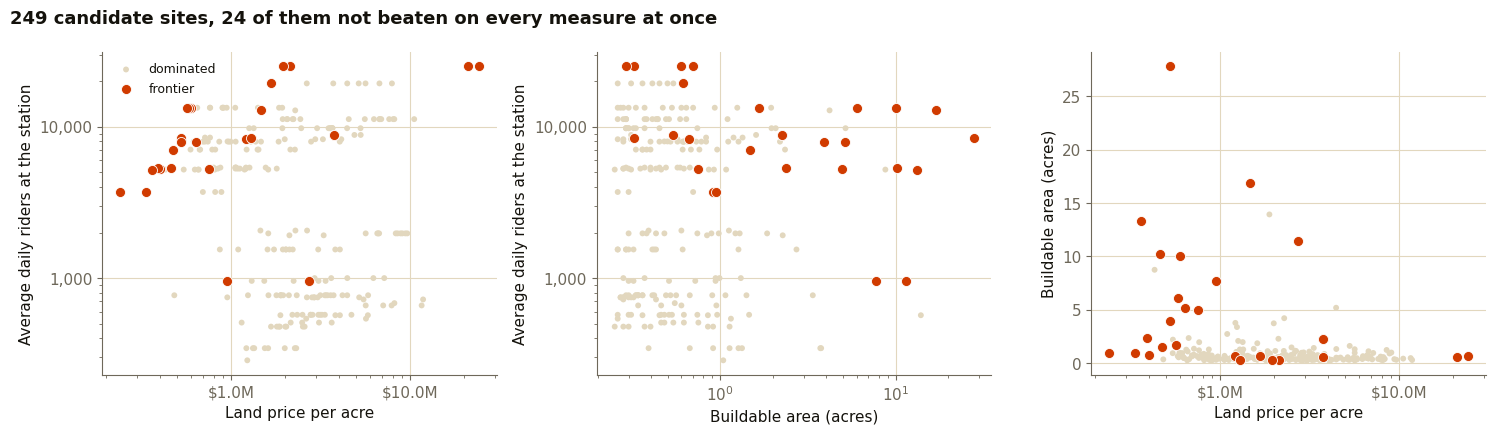

municipal
Quincy        7
Somerville    6
Cambridge     6
Revere        3
Malden        3
Braintree     1
Medford       1


In [10]:
def pareto_mask(frame, cols, lower):
    A = frame[cols].to_numpy(float).copy()
    for i, c in enumerate(cols):
        if c in lower:
            A[:, i] = -A[:, i]
    keep = np.ones(len(A), bool)
    for i in range(len(A)):
        if keep[i] and (np.all(A >= A[i], axis=1) & np.any(A > A[i], axis=1)).any():
            keep[i] = False
    return keep


site['pareto'] = pareto_mask(site, IND, LOWER_IS_BETTER)
print(f'{len(site)} sites, {site.pareto.sum()} on the frontier '
      f'({site.pareto.sum()/len(site):.0%} kept, no weights used)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
pairs = [('ppa', 'daily'), ('buildar_ac', 'daily'), ('ppa', 'buildar_ac')]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(site.loc[~site.pareto, x], site.loc[~site.pareto, y],
               s=18, color=FAINT, edgecolor='none', label='dominated')
    ax.scatter(site.loc[site.pareto, x], site.loc[site.pareto, y],
               s=52, color=ACCENT, edgecolor='white', lw=0.6, zorder=3, label='frontier')
    ax.set_xlabel(NICE[x]); ax.set_ylabel(NICE[y])
    if x == 'ppa':
        ax.set_xscale('log'); ax.xaxis.set_major_formatter(FuncFormatter(money))
    if y == 'daily':
        ax.set_yscale('log'); ax.yaxis.set_major_formatter(thousands)
    if x == 'buildar_ac':
        ax.set_xscale('log')
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle('249 candidate sites, 24 of them not beaten on every measure at once',
             x=0.005, ha='left', fontweight='bold', fontsize=13)
plt.tight_layout()
save('07-pareto')

print(site[site.pareto].groupby('municipal').size().sort_values(ascending=False).to_string())

## 08. Three kinds of site

Twenty-four is still too many to describe one at a time, and they are not one
kind of thing. Standardising the four indicators and clustering gives groups
that can be named. The silhouette score keeps creeping up past three clusters,
but three is what can be described in words, and a typology nobody can name is
not a typology. The scores are printed below so the trade is visible rather
than asserted.

silhouette by k: {2: 0.309, 3: 0.349, 4: 0.388, 5: 0.385, 6: 0.396}

                           ppa  buildar_ac    daily  peak_share  sites  frontier
Small, dear, quiet  2838888.89        0.46   745.43        0.53     99         0
Small, dear, busy   1461666.67        0.52  8268.57        0.48    141        20
Big and cheap        595818.36       11.46  5210.71        0.48      9         7


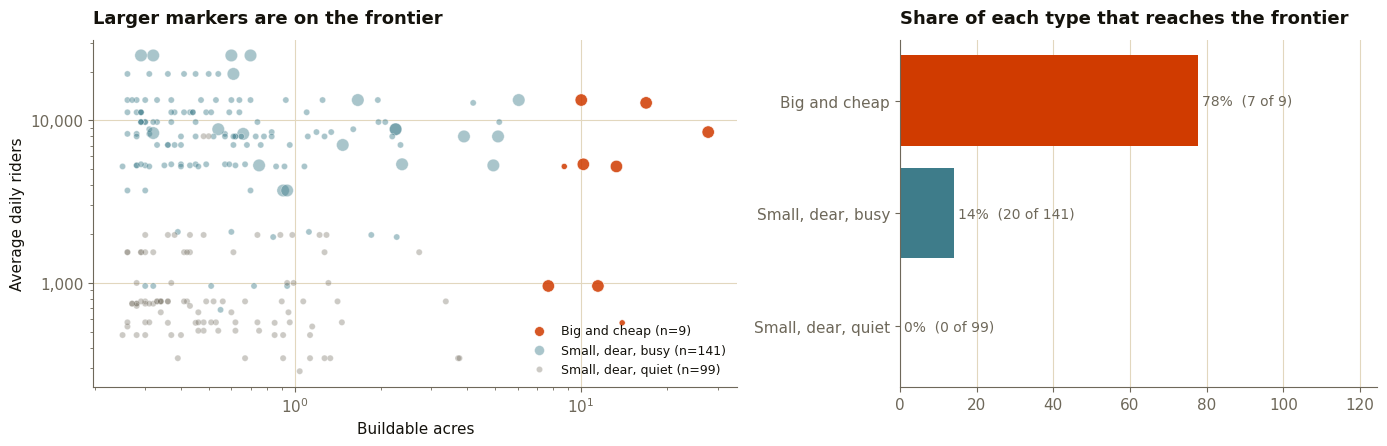


'Small, dear, quiet' is 40% of the candidate pool and 0 of 27 frontier places.
It is mostly: Brookline (31), Somerville (30), Newton (28)


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Z = StandardScaler().fit_transform(site[IND])
sil = {k: silhouette_score(Z, KMeans(k, n_init=20, random_state=7).fit_predict(Z))
       for k in range(2, 7)}
print('silhouette by k:', {k: round(v, 3) for k, v in sil.items()})

site['cluster'] = KMeans(3, n_init=20, random_state=7).fit_predict(Z)
prof = site.groupby('cluster')[IND].median()
prof['sites'] = site.groupby('cluster').size()
prof['frontier'] = site.groupby('cluster').pareto.sum()
NAMES = {int(prof.buildar_ac.idxmax()): 'Big and cheap',
         int(prof.daily.idxmax()): 'Small, dear, busy'}
for i in prof.index:
    NAMES.setdefault(int(i), 'Small, dear, quiet')
site['type'] = site.cluster.map(NAMES)
prof.index = [NAMES[int(i)] for i in prof.index]
print()
print(prof.round(2).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6),
                               gridspec_kw={'width_ratios': [1.35, 1]})
TYPE_COLOR = {'Big and cheap': ACCENT, 'Small, dear, busy': ACCENT2, 'Small, dear, quiet': MUTE}
for t, g in site.groupby('type'):
    ax1.scatter(g.buildar_ac, g.daily, s=np.where(g.pareto, 80, 20),
                color=TYPE_COLOR[t], alpha=np.where(g.pareto, 1.0, 0.35).mean(),
                edgecolor='white', lw=0.5, label=f'{t} (n={len(g)})')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Buildable acres'); ax1.set_ylabel('Average daily riders')
ax1.yaxis.set_major_formatter(thousands)
ax1.legend(frameon=False, fontsize=9, loc='lower right')
ax1.set_title('Larger markers are on the frontier')

share = (site.groupby('type').pareto.sum() / site.groupby('type').size() * 100).sort_values()
b = ax2.barh(share.index, share.values, color=[TYPE_COLOR[i] for i in share.index])
for bar, (k, v) in zip(b, share.items()):
    ax2.text(v + 1, bar.get_y() + bar.get_height() / 2,
             f'{v:.0f}%  ({site[site.type==k].pareto.sum()} of {(site.type==k).sum()})',
             va='center', fontsize=10, color=MUTE)
ax2.set_xlim(0, share.max() * 1.6)
ax2.set_title('Share of each type that reaches the frontier')
ax2.grid(axis='y', visible=False)
plt.tight_layout()
save('08-typology')

quiet = site[site.type == 'Small, dear, quiet']
print(f"\n'Small, dear, quiet' is {len(quiet)/len(site):.0%} of the candidate pool and "
      f"{quiet.pareto.sum()} of {site.pareto.sum()} frontier places.")
print('It is mostly:', ', '.join(f'{m} ({n})' for m, n in quiet.municipal.value_counts().head(3).items()))

## 09. Weights are a position, so let each position speak

I could not defend one set of weights in 2024 and I cannot now. The honest
response is not to pick harder, it is to stop pretending there is one answer.

Each scenario below is a position somebody could actually hold, written as a
weight vector. None of them is *the* answer. The spread between them is the
result.

Scores are percentiles against all 3,028 regional MAPC sites, not min-max
inside the shortlist, so a site's score does not move when the shortlist does.

In [12]:
REGION = s[s.ppa > 0]
REF = {'ppa': REGION.ppa, 'buildar_ac': s.buildar_ac.dropna(), 'jobs45tr': s.jobs45tr.dropna()}

def percentile(col):
    base = REF.get(col, site[col]).to_numpy()
    p = site[col].apply(lambda v: (base < v).mean() * 100)
    return 100 - p if col in LOWER_IS_BETTER else p

PCT = pd.DataFrame({c: percentile(c) for c in IND + ['jobs45tr']}, index=site.index)

SCENARIOS = {
    'Developer, cost first': ({'ppa': .50, 'buildar_ac': .25, 'daily': .15, 'peak_share': .10},
                              'Land is paid before anything earns. Minimise it.'),
    'City, housing first':   ({'buildar_ac': .50, 'ppa': .20, 'daily': .20, 'peak_share': .10},
                              'The zoning law exists to produce homes. Maximise how many fit.'),
    'Transit agency':        ({'daily': .40, 'peak_share': .30, 'ppa': .15, 'buildar_ac': .15},
                              'Put density where the trains already run.'),
    'All-day place':         ({'peak_share': .40, 'buildar_ac': .25, 'daily': .20, 'ppa': .15},
                              'Shops need customers at noon, not only at eight.'),
    'Regional access':       ({'jobs45tr': .40, 'daily': .20, 'ppa': .20, 'buildar_ac': .20},
                              'Put homes where the most jobs are reachable without a car.'),
    'No prior, equal':       ({'ppa': .25, 'buildar_ac': .25, 'daily': .25, 'peak_share': .25},
                              'I cannot tell these four apart, so I will not pretend to.'),
}

scores = pd.DataFrame({k: sum(PCT[c] * w for c, w in v[0].items())
                       for k, v in SCENARIOS.items()}, index=site.index)
# Several parcels can sit at one station, so the label carries the buildable
# area: without it two different sites appear as the same row in a chart.
label = (site.municipal + ' / ' + site.station + ' ('
         + site.buildar_ac.round(1).astype(str) + ' ac)')

rows = []
for k in SCENARIOS:
    for rank, i in enumerate(scores[k].nlargest(5).index, 1):
        rows.append(dict(scenario=k, rank=rank, site=label[i], line=site.line[i],
                         acres=round(site.buildar_ac[i], 1), ppa=round(site.ppa[i]),
                         daily=round(site.daily[i]), score=round(scores[k][i], 1),
                         frontier=bool(site.pareto[i])))
top5 = pd.DataFrame(rows)
winners = top5[top5['rank'] == 1].set_index('scenario')
print(winners[['site', 'line', 'acres', 'ppa', 'daily', 'score', 'frontier']].to_string())
print('\nevery scenario winner is on the frontier:', bool(winners.frontier.all()))

                                                   site    line  acres     ppa  daily  score  frontier
scenario                                                                                              
Developer, cost first   Braintree / Braintree (13.3 ac)     Red   13.3  363718   5211   75.7      True
City, housing first    Malden / Malden Center (10.0 ac)  Orange   10.0  595818  13356   82.1      True
Transit agency         Malden / Malden Center (10.0 ac)  Orange   10.0  595818  13356   78.2      True
All-day place            Revere / Revere Beach (4.9 ac)    Blue    4.9  753121   5289   78.1      True
Regional access        Malden / Malden Center (10.0 ac)  Orange   10.0  595818  13356   82.2      True
No prior, equal        Malden / Malden Center (10.0 ac)  Orange   10.0  595818  13356   75.8      True

every scenario winner is on the frontier: True


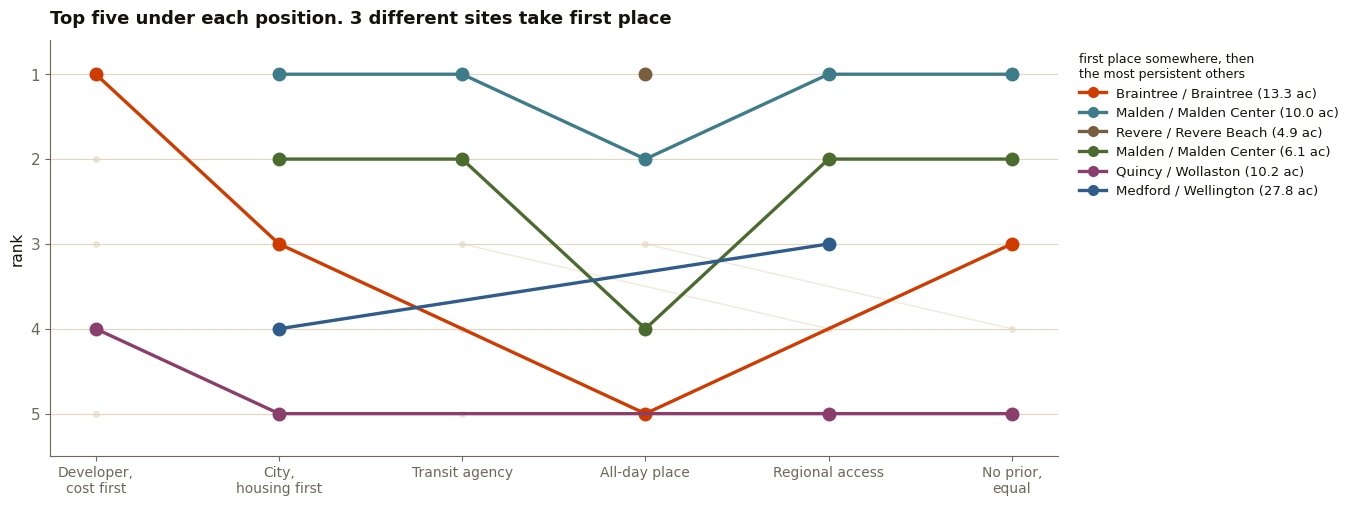

In [13]:
order = list(SCENARIOS)
shown = top5[top5['rank'] <= 5].copy()

# Every site that takes first place somewhere gets a colour, and the most
# persistent runners-up fill what is left of the palette. Choosing by frequency
# alone hid a site that wins one scenario and appears in few others, which is
# the case this chart exists to show.
champions = list(dict.fromkeys(winners.site))
others = [n for n in shown.site.value_counts().index if n not in champions]
PALETTE = [ACCENT, ACCENT2, '#7A5C3E', '#4C6B2F', '#8A3E6B', '#2F5C8A']
highlight = dict(zip((champions + others)[:len(PALETTE)], PALETTE))

fig, ax = plt.subplots(figsize=(13, 5.4))
for nm, g in shown.groupby('site'):
    g = g.sort_values('scenario', key=lambda c: c.map(order.index))
    xs = [order.index(sc) for sc in g.scenario]
    hot = nm in highlight
    ax.plot(xs, g['rank'].values, '-o', color=highlight.get(nm, FAINT),
            lw=2.4 if hot else 1, ms=9 if hot else 4,
            zorder=3 if hot else 1, alpha=1 if hot else 0.55)

# Names go in a column beside the plot. Six labels on a six-column chart collide
# wherever they are placed on the lines themselves.
handles = [plt.Line2D([], [], color=c, lw=2.4, marker='o', ms=7, label=n)
           for n, c in highlight.items()]
ax.legend(handles=handles, frameon=False, fontsize=9.5, loc='upper left',
          bbox_to_anchor=(1.01, 1.0), alignment='left',
          title='first place somewhere, then\nthe most persistent others',
          title_fontsize=9)
ax.set_xticks(range(len(order)), [o.replace(', ', ',\n') for o in order], fontsize=10)
ax.set_yticks(range(1, 6))
ax.set_ylim(5.5, 0.6)
ax.set_ylabel('rank')
ax.set_title(f'Top five under each position. {len(set(winners.site))} different sites take first place')
ax.grid(axis='x', visible=False)
save('09-scenarios')

## 10. How far does a position have to move before the answer does?

The scenarios are six points. Drawing weights at random fills in everything
between them and says how much of that space each site owns.

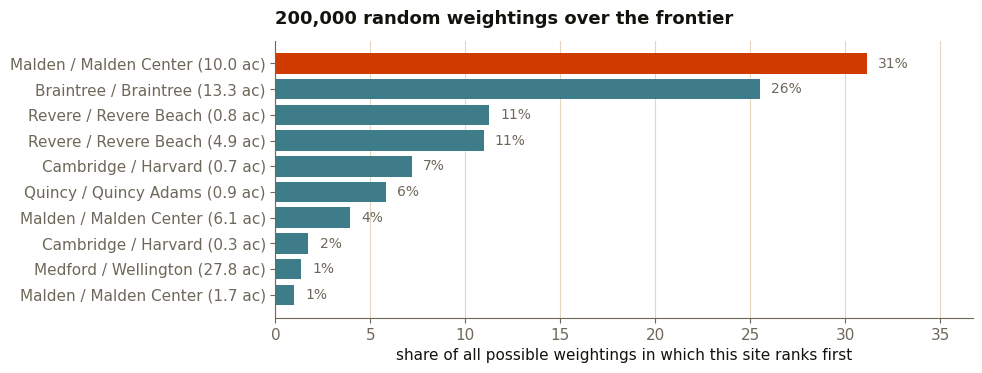

Malden / Malden Center (10.0 ac)    0.311
Braintree / Braintree (13.3 ac)     0.255
Revere / Revere Beach (0.8 ac)      0.112
Revere / Revere Beach (4.9 ac)      0.110
Cambridge / Harvard (0.7 ac)        0.072
Quincy / Quincy Adams (0.9 ac)      0.058
Malden / Malden Center (6.1 ac)     0.039
Cambridge / Harvard (0.3 ac)        0.017
Medford / Wellington (27.8 ac)      0.013
Malden / Malden Center (1.7 ac)     0.010


In [14]:
rng = np.random.default_rng(7)
F = site[site.pareto]
PF = PCT.loc[F.index, IND].to_numpy()
draws = rng.dirichlet(np.ones(len(IND)), 200_000)
wins = np.bincount(np.argmax(draws @ PF.T, axis=1), minlength=len(F)) / len(draws)
share = pd.Series(wins, index=label[F.index]).sort_values(ascending=False)
share = share[share > 0.005]

fig, ax = plt.subplots(figsize=(9, 3.6))
b = ax.barh(share.index[::-1], share.values[::-1] * 100,
            color=[ACCENT if v == share.max() else ACCENT2 for v in share.values[::-1]])
for bar, v in zip(b, share.values[::-1]):
    ax.text(v * 100 + 0.6, bar.get_y() + bar.get_height() / 2, f'{v:.0%}', va='center',
            fontsize=10, color=MUTE)
ax.set_xlabel('share of all possible weightings in which this site ranks first')
ax.set_title('200,000 random weightings over the frontier')
ax.set_xlim(0, share.max() * 118)
ax.grid(axis='y', visible=False)
save('10-weight-space')
print(share.round(3).to_string())

## 11. Does the composite beat sorting on one column?

If a weighted combination of four indicators ranks sites the same way as one of
them alone, the combination is decoration. This is the cheapest check available
and the easiest to skip.

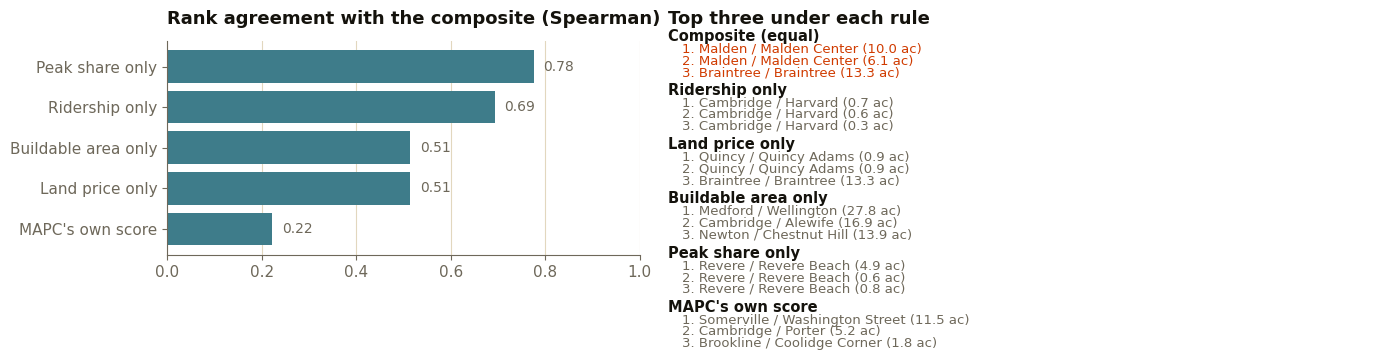

No single indicator reproduces the composite top three.
Sorting on ridership alone gives the region's busiest square;
sorting on land price alone gives the park-and-ride with the least demand.


In [15]:
BASE = {
    'Composite (equal)': scores['No prior, equal'],
    'Ridership only': site.daily,
    'Land price only': -site.ppa,
    'Buildable area only': site.buildar_ac,
    'Peak share only': -site.peak_share,
    "MAPC's own score": site.regipctile,
}
ranks = pd.DataFrame({k: v.rank(ascending=False) for k, v in BASE.items()})
agree = ranks.corr(method='spearman')['Composite (equal)'].drop('Composite (equal)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.2),
                               gridspec_kw={'width_ratios': [1, 1.5]})
a = agree.sort_values()
bars = ax1.barh(a.index, a.values, color=ACCENT2)
for bar, v in zip(bars, a.values):
    ax1.text(v + 0.02, bar.get_y() + bar.get_height() / 2, f'{v:.2f}', va='center',
             fontsize=10, color=MUTE)
ax1.set_xlim(0, 1)
ax1.set_title('Rank agreement with the composite (Spearman)')
ax1.grid(axis='y', visible=False)

tops = {k: [label[i] for i in v.nlargest(3).index] for k, v in BASE.items()}
ax2.axis('off')
y = 1.0
for k, names in tops.items():
    ax2.text(0, y, k, fontweight='bold', fontsize=10.5, transform=ax2.transAxes)
    for j, nm in enumerate(names):
        ax2.text(0.02, y - 0.055 * (j + 1), f'{j+1}. {nm}', fontsize=9.5,
                 color=ACCENT if k.startswith('Composite') else MUTE, transform=ax2.transAxes)
    y -= 0.055 * (len(names) + 1.6)
ax2.set_title('Top three under each rule')
plt.tight_layout()
save('11-baselines')

print('No single indicator reproduces the composite top three.')
print('Sorting on ridership alone gives the region\'s busiest square;')
print('sorting on land price alone gives the park-and-ride with the least demand.')

## 12. An outside opinion

MAPC scores every site in its inventory for redevelopment potential on its own
criteria — health, travel choice, growth potential — which overlap with these
four but are not the same. That makes their percentile a useful outside check:
not a ground truth, but a second reading.

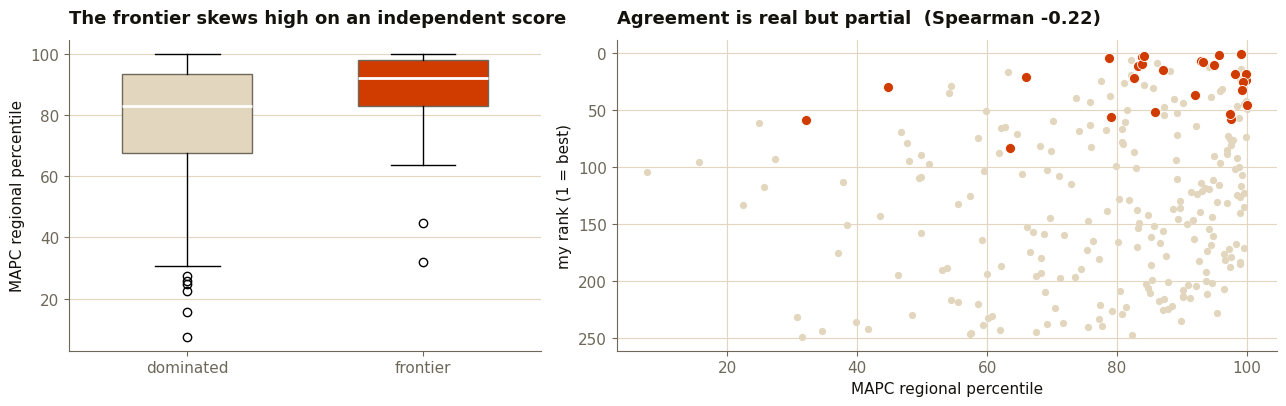

frontier median MAPC percentile 92 against 83 for the rest


In [16]:
v = site.dropna(subset=['regipctile'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2),
                               gridspec_kw={'width_ratios': [1, 1.4]})
groups = [v.loc[~v.pareto, 'regipctile'], v.loc[v.pareto, 'regipctile']]
bp = ax1.boxplot(groups, tick_labels=['dominated', 'frontier'], widths=0.55,
                 patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, c in zip(bp['boxes'], [FAINT, ACCENT]):
    patch.set_facecolor(c); patch.set_edgecolor(MUTE)
ax1.set_ylabel("MAPC regional percentile")
ax1.set_title('The frontier skews high on an independent score')
ax1.grid(axis='x', visible=False)

ax2.scatter(v.loc[~v.pareto, 'regipctile'],
            ranks.loc[v.index[~v.pareto], 'Composite (equal)'], s=18, color=FAINT)
ax2.scatter(v.loc[v.pareto, 'regipctile'], ranks.loc[v.index[v.pareto], 'Composite (equal)'],
            s=52, color=ACCENT, edgecolor='white', lw=0.6, zorder=3)
ax2.invert_yaxis()
ax2.set_xlabel("MAPC regional percentile"); ax2.set_ylabel('my rank (1 = best)')
rho = v.regipctile.corr(ranks.loc[v.index, 'Composite (equal)'], method='spearman')
ax2.set_title(f'Agreement is real but partial  (Spearman {rho:.2f})')
plt.tight_layout()
save('12-validation')

print(f"frontier median MAPC percentile {v[v.pareto].regipctile.median():.0f} "
      f"against {v[~v.pareto].regipctile.median():.0f} for the rest")

## 13. What the choice actually changes

The 2024 model gave land price the heaviest weight of the five, 30%. This runs
its cost model over each scenario winner to see how much that choice moves the
number it was supposed to protect.

                            site              scenario    ppa  buildable       land        total  land_pct  capacity_sqft
 Braintree / Braintree (13.3 ac) Developer, cost first 363718       13.3 1391636.06 480891636.06      0.29      1738044.0
Malden / Malden Center (10.0 ac)   City, housing first 595818       10.0 2279683.20 481779683.20      0.47      1306800.0
  Revere / Revere Beach (4.9 ac)         All-day place 753121        4.9 2881546.53 482381546.53      0.60       640332.0

total cost spread across the winners: $1,489,910 (0.31%)
capacity spread: 2.7x


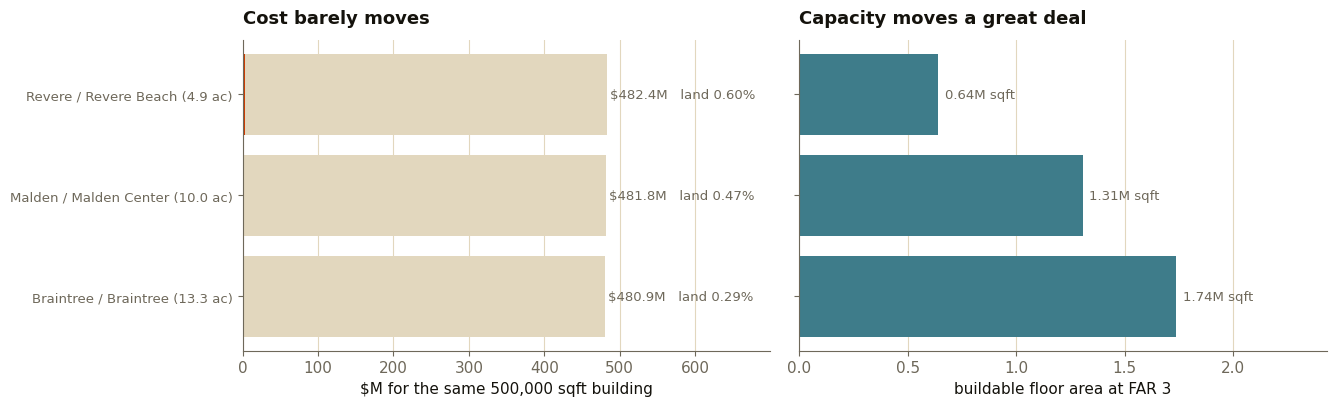

In [17]:
SQFT, FAR, BUILD_COST, SOFT = 500_000, 3, 700, 129_500_000
acres_needed = SQFT / FAR / 43_560

picks = winners.reset_index().drop_duplicates('site')
cost = pd.DataFrame({'site': picks.site.values,
                     'scenario': picks.scenario.values,
                     'ppa': picks.ppa.values,
                     'buildable': picks.acres.values})
cost['land'] = cost.ppa * acres_needed
cost['total'] = SQFT * BUILD_COST + cost.land + SOFT
cost['land_pct'] = cost.land / cost.total * 100
cost['capacity_sqft'] = cost.buildable * 43_560 * FAR
print(cost.round(2).to_string(index=False))
print(f"\ntotal cost spread across the winners: "
      f"${cost.total.max()-cost.total.min():,.0f} ({cost.total.max()/cost.total.min()-1:.2%})")
print(f"capacity spread: {cost.capacity_sqft.max()/cost.capacity_sqft.min():.1f}x")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.2), sharey=True)
y = np.arange(len(cost))
ax1.barh(y, cost.total / 1e6, color=FAINT)
ax1.barh(y, cost.land / 1e6, color=ACCENT)
for i, r in cost.iterrows():
    ax1.text(r.total / 1e6 + 4, i, f'${r.total/1e6:.1f}M   land {r.land_pct:.2f}%',
             va='center', fontsize=9.5, color=MUTE)
ax1.set_yticks(y, cost.site, fontsize=9.5)
ax1.set_xlim(0, cost.total.max() / 1e6 * 1.45)
ax1.set_xlabel('$M for the same 500,000 sqft building')
ax1.set_title('Cost barely moves')
ax1.grid(axis='y', visible=False)

ax2.barh(y, cost.capacity_sqft / 1e6, color=ACCENT2)
for i, r in cost.iterrows():
    ax2.text(r.capacity_sqft / 1e6 + 0.03, i, f'{r.capacity_sqft/1e6:.2f}M sqft',
             va='center', fontsize=9.5, color=MUTE)
ax2.set_xlim(0, cost.capacity_sqft.max() / 1e6 * 1.4)
ax2.set_xlabel('buildable floor area at FAR 3')
ax2.set_title('Capacity moves a great deal')
ax2.grid(axis='y', visible=False)
plt.tight_layout()
save('13-cost-vs-capacity')

## 14. Where the 2024 answer ended up

The point of a second pass is not to be right where the first was wrong. It is
to see what the first pass could not see.

Quincy Center: 17 candidate sites, 2 on the frontier
best of them ranks 8 of 249 under equal weights
it wins 0 of the 6 scenarios

            frontier_sites  v1_rank
municipal                          
Quincy                   7      1.0
Cambridge                6      2.0
Newton                   0      3.0
Somerville               6      4.0
Revere                   3      5.0
Malden                   3      6.0
Braintree                1      7.0
Brookline                0      8.0
Medford                  1      NaN


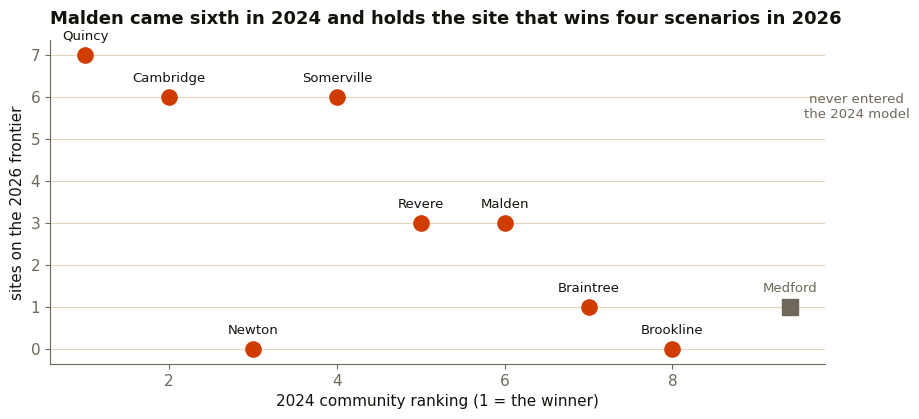

In [18]:
qc = site[site.station == 'Quincy Center']
qc_best = qc.nlargest(1, 'buildar_ac')
eq = scores['No prior, equal']
print(f'Quincy Center: {len(qc)} candidate sites, {qc.pareto.sum()} on the frontier')
print(f'best of them ranks {int(eq.rank(ascending=False)[qc_best.index[0]])} of {len(site)} under equal weights')
print(f'it wins {sum(1 for k in SCENARIOS if label[scores[k].idxmax()].startswith("Quincy / Quincy Center"))} of the {len(SCENARIOS)} scenarios')

v1_rank = {'Quincy': 1, 'Cambridge': 2, 'Newton': 3, 'Somerville': 4,
           'Revere': 5, 'Malden': 6, 'Braintree': 7, 'Brookline': 8}
cmp = pd.DataFrame({'frontier_sites': site[site.pareto].groupby('municipal').size()})
cmp = cmp.reindex(sorted(set(site.municipal))).fillna(0).astype(int)
cmp['v1_rank'] = [v1_rank.get(m, np.nan) for m in cmp.index]
cmp = cmp.sort_values('v1_rank', na_position='last')
print()
print(cmp.to_string())

fig, ax = plt.subplots(figsize=(10, 4.2))
seen = cmp.dropna(subset=['v1_rank'])
unseen = cmp[cmp.v1_rank.isna()]
ax.scatter(seen.v1_rank, seen.frontier_sites, s=120, color=ACCENT, zorder=3)
for m, r in seen.iterrows():
    ax.annotate(m, (r.v1_rank, r.frontier_sites), textcoords='offset points',
                xytext=(0, 11), ha='center', fontsize=9.5)
if len(unseen):
    xs = np.arange(len(unseen)) * 0.35 + 9.4
    ax.scatter(xs, unseen.frontier_sites, s=120, color=MUTE, marker='s', zorder=3)
    for x, (m, r) in zip(xs, unseen.iterrows()):
        ax.annotate(m, (x, r.frontier_sites), textcoords='offset points',
                    xytext=(0, 11), ha='center', fontsize=9.5, color=MUTE)
    ax.text(10.2, ax.get_ylim()[1] * 0.75, 'never entered\nthe 2024 model',
            fontsize=9.5, color=MUTE, ha='center')
ax.set_xlabel('2024 community ranking (1 = the winner)')
ax.set_ylabel('sites on the 2026 frontier')
ax.set_title('Malden came sixth in 2024 and holds the site that wins four scenarios in 2026')
ax.grid(axis='x', visible=False)
save('14-then-and-now')

**The 2024 model discarded seven of eight communities before it looked at a
single station.** Its own write-up admitted that a strong station in a
mid-ranked community would never be evaluated. That is what happened: Malden
finished sixth and holds the site that wins four of six scenarios here. Newton
finished third and holds none of the frontier. Medford was lost in the postcode
join and never entered the model at all.

Quincy Center is not a bad answer. It is still on the frontier. It was a narrow
answer, produced by a method that could not have found the alternatives.

## 15. What this version still cannot do

- **No demand-side demographics.** Nothing here describes who lives near these
  sites — income, tenure, household size — which is what anyone financing
  housing would underwrite on first.
- **Land value is assessed, not transacted.** Assessment lags the market and is
  set for taxation, not for sale.
- **The MAPC inventory is retail strip sites.** It is a good frame for
  redevelopment and it is not every developable parcel near a station.
- **The service data is one Saturday.** Enough to describe how the lines are
  built, not enough to say anything about reliability.
- **Station ridership is attributed to every site beside it.** Two parcels at
  the same station get the same demand figures, which is right for a half-mile
  catchment and wrong at the corner.
- **Nobody who works in any of these municipalities has seen this.** Every
  scenario is a position I wrote for them.

The 2024 version answered a question. This one maps out where the answer
changes, and says who would have to be asked to settle it.

In [19]:
site.to_csv('outputs/sites_scored_2026.csv', index=False) if os.path.isdir('outputs') else None
os.makedirs('outputs', exist_ok=True)
out = site[['municipal', 'station', 'line', 'type', 'pareto', 'sitearea_a', 'buildar_ac',
            'ppa', 'daily', 'peak_share', 'jobs45tr', 'regipctile']].copy()
out = out.join(scores)
out.sort_values('No prior, equal', ascending=False).to_csv('outputs/sites_scored_2026.csv', index=False)
top5.to_csv('outputs/scenario_top5.csv', index=False)
panel.to_csv('outputs/ridership_panel_2017_2025.csv')
print('written to outputs/:', sorted(os.listdir('outputs')))

written to outputs/: ['ridership_panel_2017_2025.csv', 'scenario_top5.csv', 'sites_scored_2026.csv']
